### Homework 4

#### Asymmetric quantum well

Quantum mechanics can be formulated as a matrix problem and solved on a computer using linear algebra methods. Suppose, for example, we have a particle of mass $M$ in a one-dimensional quantum well of width $L$, but not a square well like the examples you’ve probably seen before. Suppose instead that the potential $V(x)$ varies somehow inside the well:

<div align="center">
    <img src="https://raw.githubusercontent.com/jstupak/ComputationalPhysics/master/Images/asymmetricWell.png?raw=true" style="height:300px"/><br>
</div>

In general, we cannot solve such problems analytically, but we can solve them on the computer.  In a pure state of energy $E$, the spatial part of the wavefunction obeys the time-independent Schrodinger equation
$\hat{H}\psi(x) = E\psi(x)$, where the Hamiltonian operator
$\hat{H}$ is given by

\begin{equation*}
    \hat{H}=-\frac{\hbar^2}{2M}\frac{\mathrm{d}^2}{\mathrm{d}x^2}+V(x).
\end{equation*}

For simplicity, let’s assume that the walls of the well are infinitely high, so that the wavefunction is zero outside the well, and it must go to zero at $x = 0$ and $x = L$. In that case, the wavefunction can be expressed as a Fourier sine series:

\begin{equation*}
    \psi(x)=\sum_{n=1}^{\infty}\psi_n\sin\frac{n\pi x}{L},
\end{equation*}
where the $\psi_n$ are the Fourier coefficients.

a) For positive integers $m$ and $n$,
\begin{equation*}
    \int_0^L\sin\frac{m\pi x}{L}\sin\frac{n\pi x}{L}\mathrm{d}x = \delta_{mn}\frac{L}{2},
\end{equation*}
where $\delta_{mn}$ is the Kronecker delta.  Show that the Schrodinger equation $\hat{H}\psi(x) = E\psi(x)$ implies that

\begin{equation*}
    \sum_{n=1}^{\infty}\psi_n\int_0^L\sin\frac{m\pi x}{L}\hat{H}\sin\frac{n\pi x}{L}\mathrm{d}x=\frac{1}{2}LE\psi_m.
\end{equation*}

b) Hence, defining a matrix $\boldsymbol{H}$ with elements
\begin{align*}
    H_{mn} &= \frac{2}{L}\int_0^L\sin\frac{m\pi x}{L}\hat{H}\sin\frac{n\pi x}{L}\mathrm{d}x \tag{2}
\end{align*}
show that Schrodinger's equation can be written in matrix form as $\mathbf{H}\boldsymbol{\psi}=E\boldsymbol{\psi}$, where $\boldsymbol{\psi}$ is the vector $\left(\psi_1, \psi_2, \dots\right)$.

Thus, $\boldsymbol{\psi}$ is an eigenvector of the Hamiltonian matrix $\boldsymbol{H}$ with eigenvalue $E$. If we can calculate the eigenvalues of this matrix, then we know the allowed
energies of the particle in the well.

c) For the case $V(x)=ax/L$, evaluate the integral in Equation 2 analytically to find a general expression for the matrix element $H_{mn}$. Show that the matrix is real and symmetric. You’ll
probably find it useful to know that
\begin{align*}
    \int_0^L x\sin\frac{m\pi x}{L}\sin\frac{n\pi x}{L}\mathrm{d}x = \begin{cases} \mbox{0} & \mbox{if } m\neq n \mbox{ and both even or both odd}, \\ -\left(\frac{2L}{\pi}\right)^2\frac{mn}{\left(m^2-n^2\right)^2} & \mbox{if } m\neq n \mbox{ and one is even, one is odd}, \\ \frac{L^2}{4} & \mbox{if } m=n. \end{cases}
\end{align*}

d) Write code to evaluate your expression for $H_{mn}$ for arbitrary $m$ and $n$, assuming
the particle in the well is an electron ($m=9.1094 × 10^{−31}$ kg), the well has a width of $L=5\times10^{-10}$ m, and $a = 1.60218\times10^{-18}$ J.

In [1]:
import numpy as np


hbar = 1.0545718e-34
M = 9.1094e-31
L = 5e-10
a = 1.60218e-18

def H_mn(m, n):
    if m != n:
        return 0.0
    else:
        return (hbar**2 * np.pi**2 * n**2) / (2 * M * L**2)

for n in range(1, 4):
    H_nn = H_mn(n, n)
    print(f"H({n},{n}) = {H_nn/a:.4f} a")

H(1,1) = 0.1504 a
H(2,2) = 0.6016 a
H(3,3) = 1.3537 a


e) The matrix $\boldsymbol{H}$ is in theory infinitely large, so we cannot calculate all its eigenvalues. But we can get a pretty accurate solution for the first few of them by cutting off the matrix after the first few elements. Using the code you wrote for part (d) above, create a 10×10 array of the elements of $\boldsymbol{H}$ up to $m,n = 10$. Calculate the eigenvalues of this matrix using the appropriate function from `numpy.linalg` and print out the first ten energy levels of the quantum well, within this approximation. You should find, for example, that the ground-state energy of the system is around $9.35\times10^{-19}$ J. (Hint: Bear in mind that matrix indices in Python start at zero, while the indices in standard algebraic expressions, like those above, start at one. You will need to make allowances for this in your code.)

In [2]:
import numpy as np


hbar = 1.0545718e-34
M = 9.1094e-31
L = 5e-10
a = 1.60218e-18

N = 10

H = np.zeros((N, N))

for m in range(1, N+1):
    for n in range(1, N+1):
        if m == n:
            H[m-1, n-1] = (hbar**2 * np.pi**2 * n**2) / (2 * M * L**2)

eigenvalues = np.linalg.eigvalsh(H)

eigenvalues.sort()

print("First 10 energy levels (in joules and as multiples of 'a'):\n")
for i, E in enumerate(eigenvalues):
    print(f"Level {i+1}: E = {E:.4e} J  = {E/a:.4f} a")

First 10 energy levels (in joules and as multiples of 'a'):

Level 1: E = 2.4099e-19 J  = 0.1504 a
Level 2: E = 9.6395e-19 J  = 0.6016 a
Level 3: E = 2.1689e-18 J  = 1.3537 a
Level 4: E = 3.8558e-18 J  = 2.4066 a
Level 5: E = 6.0247e-18 J  = 3.7603 a
Level 6: E = 8.6755e-18 J  = 5.4148 a
Level 7: E = 1.1808e-17 J  = 7.3702 a
Level 8: E = 1.5423e-17 J  = 9.6263 a
Level 9: E = 1.9520e-17 J  = 12.1833 a
Level 10: E = 2.4099e-17 J  = 15.0411 a


f) Modify your code to use a 100×100 array instead and calculate again the first ten energy eigenvalues. Comparing with the values you calculated in part (e), what do you conclude about the accuracy of the calculation?

In [3]:
N = 100

H = np.zeros((N, N))

for m in range(1, N+1):
    H[m-1, m-1] = (hbar**2 * np.pi**2 * m**2) / (2 * M * L**2)

eigenvalues = np.linalg.eigvalsh(H)
eigenvalues.sort()

print("First 10 energy levels using 100x100 matrix:\n")
for i in range(10):
    E = eigenvalues[i]
    print(f"Level {i+1}: E = {E:.4e} J  = {E/a:.4f} a")

First 10 energy levels using 100x100 matrix:

Level 1: E = 2.4099e-19 J  = 0.1504 a
Level 2: E = 9.6395e-19 J  = 0.6016 a
Level 3: E = 2.1689e-18 J  = 1.3537 a
Level 4: E = 3.8558e-18 J  = 2.4066 a
Level 5: E = 6.0247e-18 J  = 3.7603 a
Level 6: E = 8.6755e-18 J  = 5.4148 a
Level 7: E = 1.1808e-17 J  = 7.3702 a
Level 8: E = 1.5423e-17 J  = 9.6263 a
Level 9: E = 1.9520e-17 J  = 12.1833 a
Level 10: E = 2.4099e-17 J  = 15.0411 a


The accuracy is roughly the same in both instances.

e) Calculate the wavefunction $\psi(x)$ for the ground state and the first two excited states of the well. On a single set of axes, plot the probability density $\left|\psi(x)\right|^2$ for each of these three states. Pay special attention to the normalization of the wavefunction; it should satisfy the condition $\int_0^L\left|\psi(x)\right|^2\mathrm{d}x = 1$. Is this true of your wavefunction?

Normalization of ψ₁: 1.000000
Normalization of ψ₂: 1.000000
Normalization of ψ₃: 1.000000


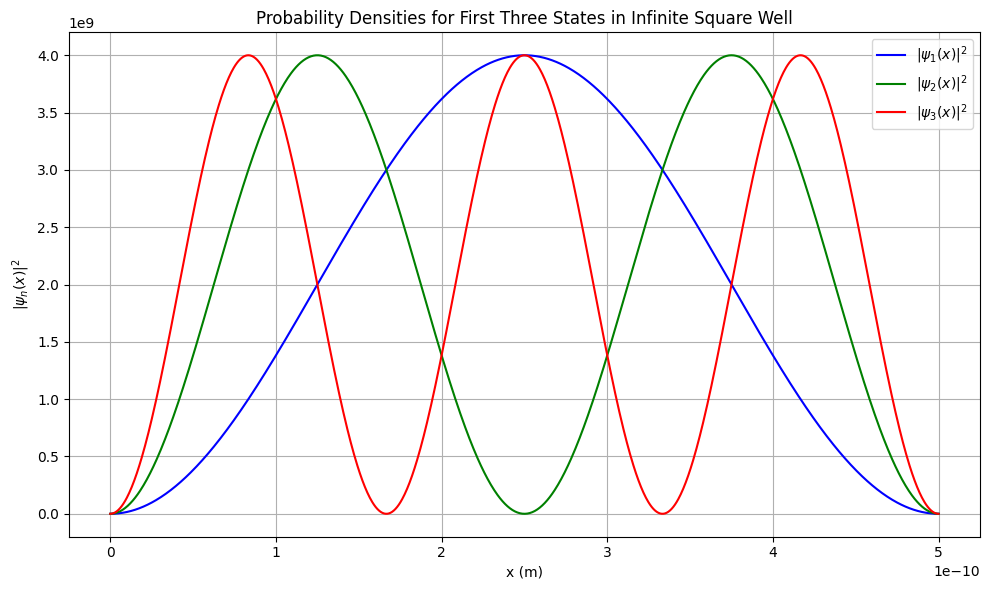

In [11]:
!pip install --upgrade scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson
L = 5e-10

def psi_n(x, n, L):
    return np.sqrt(2 / L) * np.sin(n * np.pi * x / L)

x = np.linspace(0, L, 1000)

psi1 = psi_n(x, 1, L)
psi2 = psi_n(x, 2, L)
psi3 = psi_n(x, 3, L)

prob1 = psi1**2
prob2 = psi2**2
prob3 = psi3**2

norm1 = simpson(y=prob1, x=x)
norm2 = simpson(y=prob2, x=x)
norm3 = simpson(y=prob3, x=x)

print(f"Normalization of ψ₁: {norm1:.6f}")
print(f"Normalization of ψ₂: {norm2:.6f}")
print(f"Normalization of ψ₃: {norm3:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(x, prob1, label=r'$|\psi_1(x)|^2$', color='blue')
plt.plot(x, prob2, label=r'$|\psi_2(x)|^2$', color='green')
plt.plot(x, prob3, label=r'$|\psi_3(x)|^2$', color='red')
plt.title("Probability Densities for First Three States in Infinite Square Well")
plt.xlabel("x (m)")
plt.ylabel(r"$|\psi_n(x)|^2$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()